In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("Saniya Sayyed || 221A014")

Saniya Sayyed || 221A014


In [2]:
print("Saniya Sayyed || 221A014")
# Step 1: Multi-Armed Bandit Class
class MultiArmedBandit:
    def __init__(self, k=10):
        self.k = k
        self.q_true = np.random.normal(0, 1, k)  # True reward means
        self.best_arm = np.argmax(self.q_true)

    def pull_arm(self, arm):
        return np.random.normal(self.q_true[arm], 1)  # Reward with noise


Saniya Sayyed || 221A014


In [3]:
print("Saniya Sayyed || 221A014")
# Step 2: Agent Class
class Agent:
    def __init__(self, bandit, strategy="epsilon_greedy", epsilon=0.1, c=2):
        self.bandit = bandit
        self.strategy = strategy
        self.epsilon = epsilon
        self.c = c
        self.k = bandit.k

        self.Q = np.zeros(self.k)  # Estimated values
        self.N = np.zeros(self.k)  # Count of pulls

    def select_action(self, t):
        if self.strategy == "epsilon_greedy":
            if np.random.rand() < self.epsilon:
                return np.random.randint(self.k)
            return np.argmax(self.Q)

        elif self.strategy == "ucb1":
            if 0 in self.N:
                return np.argmin(self.N)
            return np.argmax(self.Q + self.c * np.sqrt(np.log(t + 1) / self.N))

        elif self.strategy == "thompson_sampling":
            samples = np.random.normal(self.Q, 1 / (self.N + 1))
            return np.argmax(samples)

    def update(self, arm, reward):
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]


Saniya Sayyed || 221A014


In [4]:
print("Saniya Sayyed || 221A014")
# Step 3: Run Experiment
def run_strategy(k=10, steps=1000, runs=200,
                 strategies=["epsilon_greedy", "ucb1", "thompson_sampling"]):

    avg_rewards = {strategy: np.zeros(steps) for strategy in strategies}

    for strategy in strategies:
        for run in range(runs):
            bandit = MultiArmedBandit(k)
            agent = Agent(bandit, strategy=strategy)

            rewards = np.zeros(steps)

            for t in range(steps):
                action = agent.select_action(t)
                reward = bandit.pull_arm(action)

                agent.update(action, reward)
                rewards[t] = reward

            avg_rewards[strategy] += rewards / runs

    return avg_rewards

Saniya Sayyed || 221A014


In [5]:
print("Saniya Sayyed || 221A014")
# Step 4: Execute
strategies = ["epsilon_greedy", "ucb1", "thompson_sampling"]
results = run_strategy(strategies=strategies)

print(results.keys())

Saniya Sayyed || 221A014
dict_keys(['epsilon_greedy', 'ucb1', 'thompson_sampling'])


Saniya Sayyed || 221A014


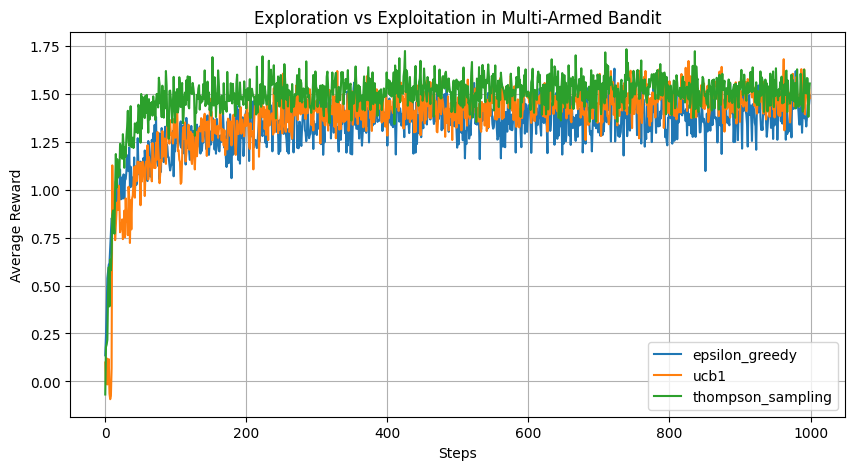

In [6]:
print("Saniya Sayyed || 221A014")
# Step 5: Plot Results
plt.figure(figsize=(10, 5))

for strategy, rewards in results.items():
    plt.plot(rewards, label=strategy)

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Exploration vs Exploitation in Multi-Armed Bandit")
plt.legend()
plt.grid()

plt.show()